# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API
**DevelopersHub Corporation — AI/ML Engineering Internship (Phase 2)**

**Objective:** Build a reusable, production-ready machine learning pipeline to predict customer churn using the Telco Customer Churn dataset. The pipeline handles preprocessing (scaling + encoding), trains Logistic Regression and Random Forest models, tunes hyperparameters with `GridSearchCV`, and exports the final pipeline with `joblib`.


In [1]:
# Cell 1: Install required libraries
!pip install -q scikit-learn pandas joblib matplotlib seaborn

## Step 1: Load Dataset (Telco Customer Churn, loaded directly from a public URL)

In [2]:
# Cell 2: Load Dataset
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Explore & Clean the Data

- `TotalCharges` is loaded as text (has some blank strings for new customers) — convert to numeric.
- Drop `customerID` since it's just an identifier, not a predictive feature.
- Target column: `Churn` (Yes/No) — convert to binary (1/0).

In [3]:
# Cell 3: Data Cleaning
# TotalCharges has some blank strings -> convert to numeric, coercing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows with missing TotalCharges (a small number of new customers with 0 tenure)
df = df.dropna(subset=["TotalCharges"])

# Drop the ID column - not predictive
df = df.drop(columns=["customerID"])

# Encode target: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Shape after cleaning:", df.shape)
print("Churn rate:", df["Churn"].mean().round(3))
df.info()

Shape after cleaning: (7032, 20)
Churn rate: 0.266
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 

## Step 3: Train/Test Split

In [4]:
# Cell 4: Split features and target
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identify column types for preprocessing
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train shape: (5625, 19)  Test shape: (1407, 19)


## Step 4: Build Preprocessing + Model Pipeline

Using `ColumnTransformer` inside a `Pipeline` so that scaling (numeric) and one-hot encoding (categorical) happen automatically and consistently — this is what makes the pipeline production-ready and reusable (the same object can be saved and reused on new raw data).

In [5]:
# Cell 5: Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

## Step 5: Train Model 1 — Logistic Regression (with GridSearchCV)

In [6]:
# Cell 6: Logistic Regression pipeline + hyperparameter tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "liblinear"]
}

logreg_grid = GridSearchCV(
    logreg_pipeline, logreg_param_grid, cv=5, scoring="f1", n_jobs=-1
)
logreg_grid.fit(X_train, y_train)

print("Best Logistic Regression params:", logreg_grid.best_params_)
print("Best CV F1-score:", logreg_grid.best_score_.round(4))

Best Logistic Regression params: {'classifier__C': 1, 'classifier__solver': 'liblinear'}
Best CV F1-score: 0.5965


## Step 6: Train Model 2 — Random Forest (with GridSearchCV)

In [7]:
# Cell 7: Random Forest pipeline + hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring="f1", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV F1-score:", rf_grid.best_score_.round(4))

Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1-score: 0.5839


## Step 7: Evaluate Both Models on the Test Set

In [8]:
# Cell 8: Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": logreg_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
}

results = []
for name, model in models.items():
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
    })
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))

results_df = pd.DataFrame(results)
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.63      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
1,Random Forest,0.791756,0.633663,0.513369,0.567208


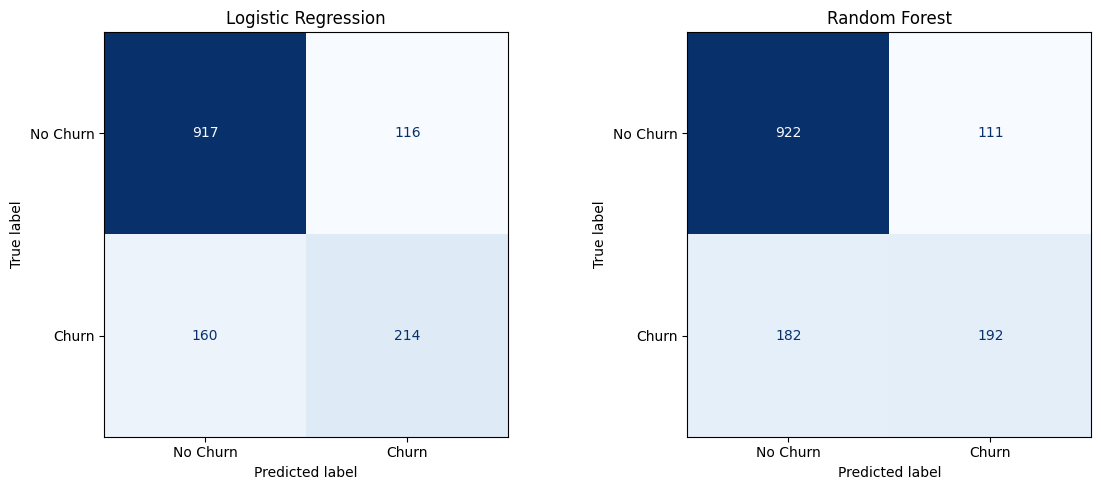

In [9]:
# Cell 9: Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Step 8: Pick the Best Model & Export the Full Pipeline with joblib

In [10]:
# Cell 10: Select best model based on F1-score and export
best_row = results_df.sort_values("F1-score", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_pipeline = models[best_model_name]

print(f"Best model: {best_model_name} (F1-score: {best_row['F1-score']:.4f})")

import joblib
joblib.dump(best_pipeline, "churn_prediction_pipeline.joblib")
print("Pipeline exported as 'churn_prediction_pipeline.joblib'")

Best model: Logistic Regression (F1-score: 0.6080)
Pipeline exported as 'churn_prediction_pipeline.joblib'


## Step 9: Demonstrate Reusability — Load the Saved Pipeline and Predict on New Data

In [11]:
# Cell 11: Reload the pipeline and test it on a few unseen samples
loaded_pipeline = joblib.load("churn_prediction_pipeline.joblib")

sample = X_test.iloc[:5]
sample_preds = loaded_pipeline.predict(sample)
sample_probs = loaded_pipeline.predict_proba(sample)[:, 1]

for i, (pred, prob) in enumerate(zip(sample_preds, sample_probs)):
    label = "Churn" if pred == 1 else "No Churn"
    print(f"Sample {i+1}: Predicted = {label}  (churn probability: {prob:.2%})")

Sample 1: Predicted = No Churn  (churn probability: 1.77%)
Sample 2: Predicted = Churn  (churn probability: 59.16%)
Sample 3: Predicted = No Churn  (churn probability: 0.49%)
Sample 4: Predicted = No Churn  (churn probability: 20.15%)
Sample 5: Predicted = No Churn  (churn probability: 10.20%)


## Final Summary / Insights

- Built a fully reusable **scikit-learn Pipeline** combining preprocessing (`StandardScaler` + `OneHotEncoder` via `ColumnTransformer`) with the model, so raw data can be fed in directly without any manual preprocessing step.
- Trained and tuned **two models** — Logistic Regression and Random Forest — using `GridSearchCV` (5-fold cross-validation, optimizing F1-score).
- Compared both models on accuracy, precision, recall, and F1-score on a held-out test set, with confusion matrices for visual comparison.
- Exported the best-performing pipeline using `joblib`, and demonstrated that it can be reloaded and used directly on new raw data — this is what makes it "production-ready."

**Skills Gained:** ML pipeline construction, hyperparameter tuning with GridSearchCV, model export & reusability, production-readiness practices.
